In [1]:
# ! pip install pandas

In [2]:
import pandas as pd
import numpy as np

In [3]:
pd.__version__

'3.0.2'

## Series

#### Basic

In [7]:
d = pd.Series([0.25, 5, -4, 1])
s = pd.Series([0.1, -5, 'a'])
e = pd.Series([False, True, True])

print(d, end='\n\n')
print(s, end='\n\n')
print(e)

0    0.25
1    5.00
2   -4.00
3    1.00
dtype: float64

0    0.1
1     -5
2      a
dtype: object

0    False
1     True
2     True
dtype: bool


In [8]:
type(d)

pandas.Series

In [9]:
d.values  # return numpy array

array([ 0.25,  5.  , -4.  ,  1.  ])

In [10]:
d.to_numpy()

array([ 0.25,  5.  , -4.  ,  1.  ])

In [11]:
d.index

RangeIndex(start=0, stop=4, step=1)

In [12]:
d.keys()

RangeIndex(start=0, stop=4, step=1)

In [13]:
d[1]

np.float64(5.0)

In [14]:
d[:2]

0    0.25
1    5.00
dtype: float64

In [15]:
d[2:0:-1]

2   -4.0
1    5.0
dtype: float64

In [14]:
d[d >= 1]

1    5.0
3    1.0
dtype: float64

In [15]:
d[(d >= 1) | (d == 0.25)]  # & - and, | - or, ^ - xor, ~ - not

0    0.25
1    5.00
3    1.00
dtype: float64

In [28]:
dict1 = {'California': 38332521,
         'Texas': 26448193,
         'New York': 19651127,
         'Florida': 19552860,
         'Illinois': 12882135}

p = pd.Series(dict1)
p

California    38332521
Texas         26448193
New York      19651127
Florida       19552860
Illinois      12882135
dtype: int64

In [29]:
dict1.keys()

dict_keys(['California', 'Texas', 'New York', 'Florida', 'Illinois'])

In [30]:
# p = pd.Series([38332521, 26448193, 19651127, 19552860, 12882135], ['California', 'Texas', 'New York', 'Texas', 'Illinois'])

In [31]:
# p

In [32]:
p['Texas']  # p[1] -> KeyError

np.int64(26448193)

In [33]:
p.loc["Texas"], p.iloc[1]

(np.int64(26448193), np.int64(26448193))

In [35]:
p['Texas':'Florida']

Texas       26448193
New York    19651127
Florida     19552860
dtype: int64

In [34]:
p[1:3]

Texas       26448193
New York    19651127
dtype: int64

In [38]:
p.drop('Texas', inplace=True)

In [39]:
p

California    38332521
New York      19651127
Florida       19552860
Illinois      12882135
dtype: int64

In [40]:
p.keys()

Index(['California', 'New York', 'Florida', 'Illinois'], dtype='str')

In [41]:
p.index

Index(['California', 'New York', 'Florida', 'Illinois'], dtype='str')

In [42]:
p.values

array([38332521, 19651127, 19552860, 12882135])

In [43]:
p.to_numpy()

array([38332521, 19651127, 19552860, 12882135])

In [44]:
ind = np.random.choice([0, 1, 2, 3], 10)
ind

array([3, 2, 2, 3, 1, 2, 3, 0, 1, 3])

In [45]:
s = pd.Series(list('abcdefghij'), ind)
s

3    a
2    b
2    c
3    d
1    e
2    f
3    g
0    h
1    i
3    j
dtype: str

In [46]:
s[1]

1    e
1    i
dtype: str

In [47]:
s.loc[1]

1    e
1    i
dtype: str

In [48]:
s.iloc[1]

'b'

In [52]:
s.iloc[[5, 6, 1]]

2    f
3    g
2    b
dtype: str

#### value_counts

In [53]:
vals = np.random.choice(list("abc"), 10)

In [54]:
s = pd.Series(vals)
s

0    b
1    b
2    a
3    a
4    c
5    a
6    c
7    b
8    b
9    c
dtype: str

In [56]:
s.value_counts(normalize=True)

b    0.4
a    0.3
c    0.3
Name: proportion, dtype: float64

#### sort_values

In [57]:
numbers = np.random.randint(-50, 50, 15)
numbers

array([-46,  12, -34, -37,  44, -47, -36, -25,  32,  -4,   5,  19,  24,
       -38, -29], dtype=int32)

In [58]:
s = pd.Series(numbers)
s

0    -46
1     12
2    -34
3    -37
4     44
5    -47
6    -36
7    -25
8     32
9     -4
10     5
11    19
12    24
13   -38
14   -29
dtype: int32

In [50]:
s.sort_values()  # doesn't change
# s

11   -47
4    -46
10   -34
12   -31
2    -22
5    -16
13   -14
0     -6
7      1
8      4
1     15
3     18
9     21
14    28
6     47
dtype: int32

In [51]:
s

0     -6
1     15
2    -22
3     18
4    -46
5    -16
6     47
7      1
8      4
9     21
10   -34
11   -47
12   -31
13   -14
14    28
dtype: int32

In [52]:
# s = s.sort_values()
s.sort_values(inplace=True)
s

11   -47
4    -46
10   -34
12   -31
2    -22
5    -16
13   -14
0     -6
7      1
8      4
1     15
3     18
9     21
14    28
6     47
dtype: int32

In [53]:
s.sort_values(ascending=False)  # max to min

6     47
14    28
9     21
3     18
1     15
8      4
7      1
0     -6
13   -14
5    -16
2    -22
12   -31
10   -34
4    -46
11   -47
dtype: int32

In [54]:
s.sort_index()

0     -6
1     15
2    -22
3     18
4    -46
5    -16
6     47
7      1
8      4
9     21
10   -34
11   -47
12   -31
13   -14
14    28
dtype: int32

#### Operations on Series

|Python Operator	|    Pandas Method(s)|
|-|-|
|+	                |add()|
|-	                |sub(), subtract()|
|*	                |mul(), multiply()|
|/	                |truediv(), div(), divide()|
|//	                |floordiv()|
|%	                |mod()|
|**	                |pow()|

In [59]:
a = [43, 54, 3, 654, np.nan, 0, 3, 543, 32, 32]

In [60]:
data = pd.Series(a)
data

0     43.0
1     54.0
2      3.0
3    654.0
4      NaN
5      0.0
6      3.0
7    543.0
8     32.0
9     32.0
dtype: float64

In [61]:
data + 2  # doesn't change data

0     45.0
1     56.0
2      5.0
3    656.0
4      NaN
5      2.0
6      5.0
7    545.0
8     34.0
9     34.0
dtype: float64

In [63]:
A = pd.Series([2, 4, 6, 7], index=[0, 1, 2, 5])
B = pd.Series([1, 3, 5], index=[1, 2, 3])

print(A, B, sep='\n\n', end='\n\n')

print(A + B, end='\n\n')

print(A.add(B, fill_value=10))

0    2
1    4
2    6
5    7
dtype: int64

1    1
2    3
3    5
dtype: int64

0    NaN
1    5.0
2    9.0
3    NaN
5    NaN
dtype: float64

0    12.0
1     5.0
2     9.0
3    15.0
5    17.0
dtype: float64


In [64]:
data < 25

0    False
1    False
2     True
3    False
4    False
5     True
6     True
7    False
8    False
9    False
dtype: bool

In [65]:
(data > 10) & ~(data < 50)

0    False
1     True
2    False
3     True
4    False
5    False
6    False
7     True
8    False
9    False
dtype: bool

In [66]:
sum(data)

nan

In [67]:
data.sum()

np.float64(1364.0)

#### apply, map

In [68]:
vals = np.random.randint(-10, 10, 20)
vals

array([  2,   0,   1,   5,  -5,   6,   4,  -3,  -6,   2,  -2,  -9,  -3,
        -4,  -7,  -1,  -1,   6,  -5, -10], dtype=int32)

In [69]:
a = pd.Series(vals)
a

0      2
1      0
2      1
3      5
4     -5
5      6
6      4
7     -3
8     -6
9      2
10    -2
11    -9
12    -3
13    -4
14    -7
15    -1
16    -1
17     6
18    -5
19   -10
dtype: int32

In [70]:
def sign(x):
    if x > 0:
        return 'Positive'
    if x < 0:
        return 'Negative'
    return "Zero"

In [71]:
a.apply(sign)  # only function

0     Positive
1         Zero
2     Positive
3     Positive
4     Negative
5     Positive
6     Positive
7     Negative
8     Negative
9     Positive
10    Negative
11    Negative
12    Negative
13    Negative
14    Negative
15    Negative
16    Negative
17    Positive
18    Negative
19    Negative
dtype: str

In [72]:
b = a.map(sign)  # function, dict or pd.Seria
b

0     Positive
1         Zero
2     Positive
3     Positive
4     Negative
5     Positive
6     Positive
7     Negative
8     Negative
9     Positive
10    Negative
11    Negative
12    Negative
13    Negative
14    Negative
15    Negative
16    Negative
17    Positive
18    Negative
19    Negative
dtype: str

In [75]:
d = {"Positive": "P", "Negative": "N", "Zero": "Z"}
b.map(d)

0     P
1     Z
2     P
3     P
4     N
5     P
6     P
7     N
8     N
9     P
10    N
11    N
12    N
13    N
14    N
15    N
16    N
17    P
18    N
19    N
dtype: str

In [77]:
# ! pip install faker

In [80]:
from faker import Faker
fake = Faker(locale="hy-am")

In [88]:
vals = (fake.name() for i in range(10))
vals

<generator object <genexpr> at 0x00000136187DCBA0>

In [89]:
a = pd.Series(vals)
a

0     Վարուժան Բազունց
1     Արգամ Չախմախչյան
2       Նաիրի Ասլանյան
3       Օհան Ազարիկյան
4      Օֆելյա Վարոսյան
5       Տաթևիկ Թառայան
6    Մելքում Ալաբեկյան
7       Արմեն Միսակյան
8       Սոնա Զոհրաբյան
9       Հիլդա Խուդոյան
dtype: str

In [90]:
a.apply(lambda x: x.split()[-1])

0       Բազունց
1    Չախմախչյան
2      Ասլանյան
3     Ազարիկյան
4      Վարոսյան
5       Թառայան
6     Ալաբեկյան
7      Միսակյան
8     Զոհրաբյան
9      Խուդոյան
dtype: str

#### str

In [91]:
m = pd.Series(['Graham Chapman', 'John Cleese', 'Terry Gilliam',
               'Eric Idle', 'Terry Jones', 'Michael Palin'])
m

0    Graham Chapman
1       John Cleese
2     Terry Gilliam
3         Eric Idle
4       Terry Jones
5     Michael Palin
dtype: str

In [92]:
m.str.lower()

0    graham chapman
1       john cleese
2     terry gilliam
3         eric idle
4       terry jones
5     michael palin
dtype: str

In [93]:
m.apply(str.lower)

0    graham chapman
1       john cleese
2     terry gilliam
3         eric idle
4       terry jones
5     michael palin
dtype: str

In [94]:
m.str.len()

0    14
1    11
2    13
3     9
4    11
5    13
dtype: int64

In [95]:
m.str.split()

0    [Graham, Chapman]
1       [John, Cleese]
2     [Terry, Gilliam]
3         [Eric, Idle]
4       [Terry, Jones]
5     [Michael, Palin]
dtype: object

Nearly all Python's built-in string methods are mirrored by a Pandas vectorized string method.
Here is a list of Pandas str methods that mirror Python string methods:


- len()	    
- lower()	        
- translate()	    
- islower()
- ljust()	    
- upper()	        
- startswith()	
- isupper()
- rjust()	    
- find()	        
- endswith()	    
- isnumeric()
- center()	
- rfind()	        
- isalnum()	    
- isdecimal()
- zfill()	    
- index()	        
- isalpha()	    
- split()
- strip()	    
- rindex()	    
- isdigit()	    
- rsplit()
- rstrip()	
- capitalize()	
- isspace()	    
- partition()
- lstrip()	
- swapcase()	    
- istitle()	    
- rpartition()

In addition, there are several methods that accept regular expressions
to examine the content of each string element,
and follow some of the API conventions of Python's built-in re module:

|Method	    |Description|
|-|-|
|match()	|    Call re.match() on each element, returning a boolean.|
|extract()	|Call re.match() on each element, returning matched groups as strings.|
|findall()	|Call re.findall() on each element|
|replace()	|Replace occurrences of pattern with some other string|
|contains()	|Call re.search() on each element, returning a boolean|
|count()	|    Count occurrences of pattern|
|split()	|    Equivalent to str.split(), but accepts regexps|
|rsplit()	|Equivalent to str.rsplit(), but accepts regexps|

Finally, there are some miscellaneous methods that enable other convenient operations:

|Method	            |Description|
|-|-|
|get()	            |Index each element|
|slice()	        |    Slice each element|
|slice_replace()	|    Replace slice in each element with passed value|
|cat()	            |Concatenate strings|
|repeat()	        |Repeat values|
|normalize()	    |    Return Unicode form of string|
|pad()	            |Add whitespace to left, right, or both sides of strings|
|wrap()	            |Split long strings into lines with length less than a given width|
|join()	            |Join strings in each element of the Series with passed separator|
|get_dummies()	    |extract dummy variables as a dataframe|

## DataFrame

#### Basic

In [98]:
dict_pop = {'California': 38332521,
            'Texas': 26448193,
            'New York': 19651127,
            'Florida': 19552860,
            'Illinois': 12882135}

pop = pd.Series(dict_pop)

dict_area = {'California': 423967,
             'Yerevan': 695662,
             'New York': 141297,
             'Florida': 170312,
             'Illinois': 149995}

area = pd.Series(dict_area)

states = pd.DataFrame({'population': pop,
                       'area': area})

states

,population,area
California,38332521.0,423967.0
Florida,19552860.0,170312.0
Illinois,12882135.0,149995.0
New York,19651127.0,141297.0
Texas,26448193.0,NaN
Yerevan,NaN,695662.0


In [99]:
type(states)

pandas.DataFrame

In [100]:
print(states)

            population      area
California  38332521.0  423967.0
Florida     19552860.0  170312.0
Illinois    12882135.0  149995.0
New York    19651127.0  141297.0
Texas       26448193.0       NaN
Yerevan            NaN  695662.0


In [101]:
states.info(memory_usage='deep')

<class 'pandas.DataFrame'>
Index: 6 entries, California to Yerevan
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   population  5 non-null      float64
 1   area        5 non-null      float64
dtypes: float64(2)
memory usage: 435.0 bytes


In [85]:
print(states.shape, '\n', states.ndim)

(5, 2) 
 2


In [102]:
states.index  # row names

Index(['California', 'Florida', 'Illinois', 'New York', 'Texas', 'Yerevan'], dtype='str')

In [103]:
states.columns  # column names

Index(['population', 'area'], dtype='str')

In [104]:
states.values  # values

array([[38332521.,   423967.],
       [19552860.,   170312.],
       [12882135.,   149995.],
       [19651127.,   141297.],
       [26448193.,       nan],
       [      nan,   695662.]])

In [105]:
states['area']

California    423967.0
Florida       170312.0
Illinois      149995.0
New York      141297.0
Texas              NaN
Yerevan       695662.0
Name: area, dtype: float64

In [106]:
states.area

California    423967.0
Florida       170312.0
Illinois      149995.0
New York      141297.0
Texas              NaN
Yerevan       695662.0
Name: area, dtype: float64

In [107]:
pd.DataFrame(pop, columns=['population'])

,population
California,38332521
Texas,26448193
New York,19651127
Florida,19552860
Illinois,12882135


In [110]:
pd.DataFrame([pop, area], index=['population', 'area'])

,California,Texas,New York,Florida,Illinois,Yerevan
population,38332521.0,26448193.0,19651127.0,19552860.0,12882135.0,NaN
area,423967.0,NaN,141297.0,170312.0,149995.0,695662.0


In [111]:
pd.DataFrame([{'a': 1, 'b': 2, 'c':8}, 
              {'b': 3, 'c': 4},
              {'a': 4, 'c': 0, 'd': 10}])

,a,b,c,d
0,1.0,2.0,8,NaN
1,NaN,3.0,4,NaN
2,4.0,NaN,0,10.0


In [112]:
pd.DataFrame(np.random.rand(3, 2),
             columns=['col_1', 'col_2'],
             index=['row_1', 'row_2', 'row_3'])

,col_1,col_2
row_1,0.549784,0.462496
row_2,0.965758,0.058984
row_3,0.867281,0.258146


#### Change DataFrame

In [113]:
pop = pd.Series({'California': 38332521, 'Texas': 26448193,
                 'New York': 19651127, 'Florida': 19552860,
                 'Illinois': 12882135})

area = pd.Series({'California': 423967, 'Texas': 695662,
                  'New York': 141297, 'Florida': 170312,
                  'Illinois': 149995})

data = pd.DataFrame({'pop': pop, 'area': area})
data

,pop,area
California,38332521,423967
Texas,26448193,695662
New York,19651127,141297
Florida,19552860,170312
Illinois,12882135,149995


In [114]:
data['density'] = data['pop'] / data['area']
data

,pop,area,density
California,38332521,423967,90.413926
Texas,26448193,695662,38.018740
New York,19651127,141297,139.076746
Florida,19552860,170312,114.806121
Illinois,12882135,149995,85.883763


In [115]:
data.area == data['area']

California    True
Texas         True
New York      True
Florida       True
Illinois      True
Name: area, dtype: bool

In [116]:
data.iloc[:3, :2]

,pop,area
California,38332521,423967
Texas,26448193,695662
New York,19651127,141297


In [117]:
data.loc[:'New York', :'area']

,pop,area
California,38332521,423967
Texas,26448193,695662
New York,19651127,141297


In [118]:
data.loc[data.density > 100]

,pop,area,density
New York,19651127,141297,139.076746
Florida,19552860,170312,114.806121


In [119]:
data.loc[data.density > 100, ['pop', 'density']]

,pop,density
New York,19651127,139.076746
Florida,19552860,114.806121


In [120]:
data.mean(axis=0)

pop        2.337337e+07
area       3.162466e+05
density    9.363986e+01
dtype: float64

In [121]:
data.iloc[0, 2] = 90
data

,pop,area,density
California,38332521,423967,90.000000
Texas,26448193,695662,38.018740
New York,19651127,141297,139.076746
Florida,19552860,170312,114.806121
Illinois,12882135,149995,85.883763


#### NaN

In [122]:
data = pd.Series([1, np.nan, 'hello', None])

data.isnull()

0    False
1     True
2    False
3     True
dtype: bool

In [108]:
data.isna()

0    False
1     True
2    False
3     True
dtype: bool

In [109]:
data.notna()

0     True
1    False
2     True
3    False
dtype: bool

In [110]:
data.notnull()

0     True
1    False
2     True
3    False
dtype: bool

In [123]:
data[data.isnull()]

1     NaN
3    None
dtype: object

In [124]:
data[data.notnull()]

0        1
2    hello
dtype: object

In [113]:
data1 = data.dropna()
# data.dropna(inplace=True)
data1

0        1
2    hello
dtype: object

In [125]:
df = pd.DataFrame([[1,      np.nan, 2],
                   [2,      3,      5],
                   [np.nan, 4,      6]], )

df

,0,1,2
0,1.0,NaN,2
1,2.0,3.0,5
2,NaN,4.0,6


In [126]:
df1 = df.dropna(axis='rows')  # by default (по умолчанию) axis = 0, 'rows'=0, 'columns'=1

df1

,0,1,2
1,2.0,3.0,5


In [127]:
df2 = df.dropna(axis='columns')  # удаляет те столбцы, где есть элемент None

df2

,2
0,2
1,5
2,6


In [117]:
df[3] = np.nan

df

,0,1,2,3
0,1.0,NaN,2,NaN
1,2.0,3.0,5,NaN
2,NaN,4.0,6,NaN


In [118]:
df3 = df.dropna(axis='columns', how='all')  # 'all' - удаляет те столбцы, где все элементы None

df3

,0,1,2
0,1.0,NaN,2
1,2.0,3.0,5
2,NaN,4.0,6


In [119]:
df4 = df.dropna(axis='columns', how='any')  # 'amy' - удаляет те столбцы, где хоть один элемент None

df4

,2
0,2
1,5
2,6


In [120]:
df5 = df.dropna(axis='rows', thresh=3)  # удаляет те строки, где есть минимум n (в данном случае 3) не None элементы

df5

,0,1,2,3
1,2.0,3.0,5,NaN


In [128]:
data = pd.Series([1, np.nan, 2, None, 3], index=list('abcde'))

data

a    1.0
b    NaN
c    2.0
d    NaN
e    3.0
dtype: float64

In [129]:
data1 = data.fillna(0)  # заполняет вместо None нули

data1

a    1.0
b    0.0
c    2.0
d    0.0
e    3.0
dtype: float64

In [126]:
data.ffill()  # заполняет вместо None предыдущими элементами

a    1.0
b    1.0
c    2.0
d    2.0
e    3.0
dtype: float64

In [127]:
data.bfill() # заполняет вместо None следующими элементами

a    1.0
b    2.0
c    2.0
d    3.0
e    3.0
dtype: float64

In [129]:
df = pd.DataFrame([[1,      np.nan, 2],
                   [2,      3,      5],
                   [np.nan, 4,      6]])

df1 = df.ffill(axis=1)

df1

,0,1,2
0,1.0,1.0,2.0
1,2.0,3.0,5.0
2,NaN,4.0,6.0


#### Stack

In [130]:
df = pd.DataFrame(np.random.rand(4, 2),
                  index=[['a', 'a', 'b', 'b'], [1, 2, 1, 2]],
                  columns=['data1', 'data2'])

df

data1     data2
a 1  0.177611  0.716327
  2  0.730250  0.219032
b 1  0.418862  0.980921
  2  0.739158  0.245448

In [131]:
df.stack()

a  1  data1    0.177611
      data2    0.716327
   2  data1    0.730250
      data2    0.219032
b  1  data1    0.418862
      data2    0.980921
   2  data1    0.739158
      data2    0.245448
dtype: float64

In [132]:
data = {('California', 2000): 33871648,
        ('California', 2010): 37253956,
        ('Texas', 2000): 20851820,
        ('Texas', 2010): 25145561,
        ('New York', 2000): 18976457,
        ('New York', 2010): 19378102}

d = pd.Series(data)
d

California  2000    33871648
            2010    37253956
Texas       2000    20851820
            2010    25145561
New York    2000    18976457
            2010    19378102
dtype: int64

#### Concat, merge, join

In [133]:
ser1 = pd.Series(['A', 'B', 'C'], index=[1, 2, 3])
ser2 = pd.Series(['D', 'E', 'F'], index=[4, 5, 6])

pd.concat([ser1, ser2])

1    A
2    B
3    C
4    D
5    E
6    F
dtype: str

In [133]:
df1 = pd.DataFrame({'employee': ['Bob', 'Jake', 'Lyova', 'Sue'],
                    'group': ['Accounting', 'Engineering', 'Engineering', 'HR']})

df1

,employee,group
0,Bob,Accounting
1,Jake,Engineering
2,Lyova,Engineering
3,Sue,HR


In [143]:
df2 = pd.DataFrame({'emp_year': ['Lisa', 'Bob', 'Jake', 'Sue'],
                    'hire_date': [2004, 2008, 2012, 2014]})

df2

,emp_year,hire_date
0,Lisa,2004
1,Bob,2008
2,Jake,2012
3,Sue,2014


In [147]:
df3 = pd.merge(left=df1, right=df2, how='outer', on=None, sort=False, left_on="employee", right_on="emp_year")
df3

,employee,group,emp_year,hire_date
0,Bob,Accounting,Bob,2008.0
1,Jake,Engineering,Jake,2012.0
2,NaN,NaN,Lisa,2004.0
3,Lyova,Engineering,NaN,NaN
4,Sue,HR,Sue,2014.0


In [143]:
df4 = pd.DataFrame({'group': ['Accounting', 'Engineering', 'HR'],
                    'supervisor': ['Carly', 'Guido', 'Steve']})

df4

,group,supervisor
0,Accounting,Carly
1,Engineering,Guido
2,HR,Steve


In [144]:
pd.merge(df3, df4)

,employee,group,hire_date,supervisor
0,Bob,Accounting,2008,Carly
1,Jake,Engineering,2012,Guido
2,Lisa,Engineering,2004,Guido
3,Sue,HR,2014,Steve


<a href='https://newtechaudit.ru/pandas-merge-join-concatenate/#:~:text=Join%20%D0%B8%20merge%20%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0%D1%8E%D1%82%20%D1%81%D0%BE,%D0%BD%D0%B5%20%D0%B4%D0%B0%D0%B5%D1%82%20%D0%BF%D0%B5%D1%80%D0%B5%D0%B8%D0%BC%D0%B5%D0%BD%D0%BE%D0%B2%D1%8B%D0%B2%D0%B0%D1%82%D1%8C%20%D1%81%D1%82%D1%80%D0%BE%D0%BA%D0%B8%2F%D1%81%D1%82%D0%BE%D0%BB%D0%B1%D1%86%D1%8B.'>Join-Merge-Concat-Append</a>

<a href='https://pandas.pydata.org/docs/user_guide/merging.html'>Merge, join, concatenate and compare</a>

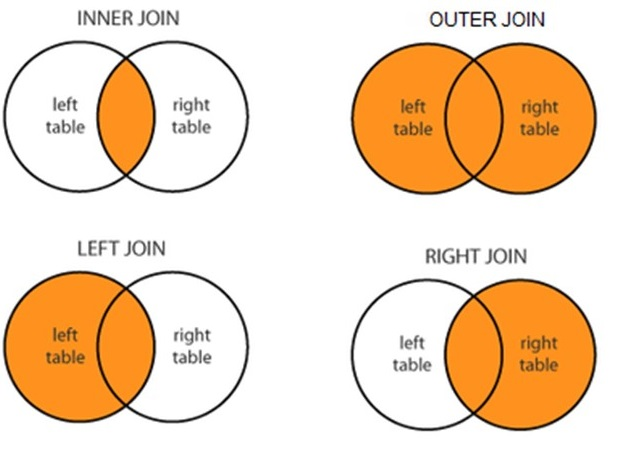

#### Other methods

In [145]:
df = pd.DataFrame({'A': np.random.rand(5),
                   'B': np.random.rand(5)})

df

,A,B
0,0.070156,0.471073
1,0.057130,0.059347
2,0.120084,0.489846
3,0.460472,0.691536
4,0.590350,0.618338


In [146]:
df.mean()  # axis = 0

A    0.259638
B    0.466028
dtype: float64

In [147]:
df.mean(axis='columns')  # axis = 1

0    0.270615
1    0.058238
2    0.304965
3    0.576004
4    0.604344
dtype: float64

|Aggregation	        |Description|
|-|-|
|count()	            |Total number of items|
|first(), last()	    |First and last item|
|mean(), median()	    |Mean and median|
|min(), max()	        |Minimum and maximum|
|std(), var()	        |Standard deviation and variance|
|mad()	                |Mean absolute deviation|
|prod()	                |Product of all items|
|sum()	                |Sum of all items|

#### Groupby

In [148]:
df = pd.DataFrame({'key': ['A', 'B', 'C', 'A', 'B', 'C'],
                   'data': range(6)},
                  columns=['key', 'data'])

df

,key,data
0,A,0
1,B,1
2,C,2
3,A,3
4,B,4
5,C,5


In [150]:
df.groupby('key')

In [1]:
df.groupby('key').sum()

NameError: name 'df' is not defined

In [153]:
df.groupby('key').mean()

,data
key,
A,1.5
B,2.5
C,3.5


In [154]:
df = pd.DataFrame({'key': ['A', 'B', 'C', 'A', 'B', 'C'],
                   'data1': range(6),
                   'data2': np.random.randint(0, 10, 6)})

df

,key,data1,data2
0,A,0,7
1,B,1,8
2,C,2,8
3,A,3,8
4,B,4,0
5,C,5,2


In [155]:
df.groupby('key').sum()

,data1,data2
key,,
A,3,15
B,5,8
C,7,10


In [156]:
df.groupby('key').aggregate([min, np.median, max, sum])

data1                data2               
      min median max sum   min median max sum
key                                          
A       0    1.5   3   3     7    7.5   8  15
B       1    2.5   4   5     0    4.0   8   8
C       2    3.5   5   7     2    5.0   8  10

In [157]:
df.groupby('key').aggregate({'data1': 'min', 'data2': 'max'})

,data1,data2
key,,
A,0,8
B,1,8
C,2,8


In [158]:
df.groupby('key').transform(lambda x: x - x.mean())

,data1,data2
0,-1.5,-0.5
1,-1.5,4.0
2,-1.5,3.0
3,1.5,0.5
4,1.5,-4.0
5,1.5,-3.0


#### get_dummies (one-hot encoding)

In [159]:
df = pd.DataFrame({'Color': ['Red', 'Green', 'Blue', 'Yellow', 'White', 'Black', 'Brown', 'Gray', 'Pink', 'Purple'], 
                   'Size': ['S', 'M', 'M', 'L', 'S', np.nan, 'L', 'S', 'M', 'L']})
df

,Color,Size
0,Red,S
1,Green,M
2,Blue,M
3,Yellow,L
4,White,S
5,Black,NaN
6,Brown,L
7,Gray,S
8,Pink,M
9,Purple,L


In [163]:
pd.get_dummies(df, columns=['Size'], dtype="int8", dummy_na=False, drop_first=False)

,Color,Size_L,Size_M,Size_S
0,Red,0,0,1
1,Green,0,1,0
2,Blue,0,1,0
3,Yellow,1,0,0
4,White,0,0,1
5,Black,0,0,0
6,Brown,1,0,0
7,Gray,0,0,1
8,Pink,0,1,0
9,Purple,1,0,0


#### datetime

In [37]:
myser = pd.Series(['Nov 3, 2000', 'Jan 1, 1999', None])
myser

0    Nov 3, 2000
1    Jan 1, 1999
2            NaN
dtype: str

In [38]:
pd.to_datetime(myser, format="%b %d, %Y")  # this is default data format

0   2000-11-03
1   1999-01-01
2          NaT
dtype: datetime64[us]

|Directive     | Meaning
|-             | -
|%a            | Locale’s abbreviated weekday name.
|%A            | Locale’s full weekday name.
|%b            | Locale’s abbreviated month name.
|%B            | Locale’s full month name.
|%c            | Locale’s appropriate date and time representation.
|%d            | Day of the month as a decimal number [01,31].
|%f            | Microseconds as a decimal number [000000,999999].
|%H            | Hour (24-hour clock) as a decimal number [00,23].
|%I            | Hour (12-hour clock) as a decimal number [01,12].
|%j            | Day of the year as a decimal number [001,366].
|%m            | Month as a decimal number [01,12].
|%M            | Minute as a decimal number [00,59].
|%p            | Locale’s equivalent of either AM or PM.
|%S            | Second as a decimal number [00,61].
|%U            | Week number of the year (Sunday as the first day of the week) as a decimal number [00,53]. All days in a new year preceding the first Sunday are considered to be in week 0.
|%u            | Day of the week (Monday is 1; Sunday is 7) as a decimal number [1, 7].
|%w            | Weekday as a decimal number [0(Sunday),6].
|%W            | Week number of the year (Monday as the first day of the week) as a decimal number [00,53]. All days in a new year preceding the first Monday are considered to be in week 0.
|%x            | Locale’s appropriate date representation.
|%X            | Locale’s appropriate time representation.
|%y            | Year without century as a decimal number [00,99].
|%Y            | Year with century as a decimal number.
|%z            | Time zone offset indicating a positive or negative time difference from UTC/GMT of the form +HHMM or -HHMM, where H represents decimal hour digits and M represents decimal minute digits [-23:59, +23:59]. [1]
|%Z
|Time zone |name| (no characters if no time zone exists). Deprecated. [1]
|%G            | ISO 8601 year (similar to %Y but follows the rules for the ISO 8601 calendar year). The year starts with the week that contains the first Thursday of the calendar year.
|%V            | ISO 8601 week number (as a decimal number [01,53]). The first week of the year is the one that contains the first Thursday of the year. Weeks start on Monday.
|%%            | A literal '%' character.

In [39]:
pd.to_datetime(myser)[0]

Timestamp('2000-11-03 00:00:00')

In [41]:
sales = pd.read_csv(r'C:\Users\user\Desktop\SC\Datasets\others\RetailSales_BeerWineLiquor.csv')
sales

,DATE,MRTSSM4453USN
0,1992-01-01,1509
1,1992-02-01,1541
2,1992-03-01,1597
3,1992-04-01,1675
4,1992-05-01,1822
...,...,...
335,2019-12-01,6630
336,2020-01-01,4388
337,2020-02-01,4533
338,2020-03-01,5562


In [42]:
sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 340 entries, 0 to 339
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   DATE           340 non-null    str  
 1   MRTSSM4453USN  340 non-null    int64
dtypes: int64(1), str(1)
memory usage: 5.4 KB


In [43]:
sales = pd.read_csv(r'C:\Users\user\Desktop\SC\Datasets\others\RetailSales_BeerWineLiquor.csv', parse_dates=[0])
sales

,DATE,MRTSSM4453USN
0,1992-01-01,1509
1,1992-02-01,1541
2,1992-03-01,1597
3,1992-04-01,1675
4,1992-05-01,1822
...,...,...
335,2019-12-01,6630
336,2020-01-01,4388
337,2020-02-01,4533
338,2020-03-01,5562


In [44]:
sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 340 entries, 0 to 339
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   DATE           340 non-null    datetime64[us]
 1   MRTSSM4453USN  340 non-null    int64         
dtypes: datetime64[us](1), int64(1)
memory usage: 5.4 KB


In [45]:
sales.index

RangeIndex(start=0, stop=340, step=1)

In [46]:
sales = sales.set_index("DATE")

In [47]:
sales

,MRTSSM4453USN
DATE,
1992-01-01,1509
1992-02-01,1541
1992-03-01,1597
1992-04-01,1675
1992-05-01,1822
...,...
2019-12-01,6630
2020-01-01,4388
2020-02-01,4533


<table style="display: inline-block; margin-left: 40px">
<caption style="text-align: center"></caption>
<tr><td>us or nus</td><td>Microsecondly</td></tr>
<tr><td>ms or nms</td><td>Millisecondly</td></tr>
<tr><td>s or ns</td><td>Secondly</td></tr>
<tr><td>min or nmin</td><td>Minutely</td></tr>
<tr><td>h or nh</td><td>Hourly</td></tr>
<tr><td>D or nD</td><td>Daily</td></tr>
<tr><td>B or nB</td><td>Business Daily</td></tr>
<tr><td>W or nW</td><td>Weekly</td></tr>
<tr><td>ME or nME</td><td>Month End</td></tr>
<tr><td>MS or nMS</td><td>Month Start</td></tr>
<tr><td>QE or nQE</td><td>Quarter End</td></tr>
<tr><td>QS or nQS</td><td>Quarter Start</td></tr
<tr><td>YE or nYE</td><td>Year End</td></tr>
<tr><td>YS or nYS</td><td>Year Start</td></tr
</tr</table>

Вместо `n` нужное количество минут \ часов \ дней \ месяцев и т.д.

In [66]:
sales.resample(rule='3MS').mean()  # every 3 mounts

,MRTSSM4453USN
DATE,
1992-01-01,1549.000000
1992-04-01,1757.333333
1992-07-01,1848.000000
1992-10-01,2074.666667
1993-01-01,1607.000000
...,...
2019-04-01,4900.000000
2019-07-01,5065.000000
2019-10-01,5618.333333


In [54]:
sales.resample(rule='100D').mean()  # every 100 days

,MRTSSM4453USN
DATE,
1992-01-01,1509.0
1992-01-11,NaN
1992-01-21,NaN
1992-01-31,1541.0
1992-02-10,NaN
...,...
2020-02-13,NaN
2020-02-23,5562.0
2020-03-04,NaN


In [67]:
sales = sales.reset_index()

In [68]:
sales

,DATE,MRTSSM4453USN
0,1992-01-01,1509
1,1992-02-01,1541
2,1992-03-01,1597
3,1992-04-01,1675
4,1992-05-01,1822
...,...,...
335,2019-12-01,6630
336,2020-01-01,4388
337,2020-02-01,4533
338,2020-03-01,5562


In [73]:
sales['DATE'].dt.year

0      1992
1      1992
2      1992
3      1992
4      1992
       ... 
335    2019
336    2020
337    2020
338    2020
339    2020
Name: DATE, Length: 340, dtype: int32

In [79]:
sales["DATE"].dt.day_of_year

0        1
1       32
2       61
3       92
4      122
      ... 
335    335
336      1
337     32
338     61
339     92
Name: DATE, Length: 340, dtype: int32

In [80]:
sales['DATE'].dt.is_leap_year

0       True
1       True
2       True
3       True
4       True
       ...  
335    False
336     True
337     True
338     True
339     True
Name: DATE, Length: 340, dtype: bool

## Read data

<table border="1" class="colwidths-given docutils">
<colgroup>
<col width="12%" />
<col width="40%" />
<col width="24%" />
<col width="24%" />
</colgroup>
<thead valign="bottom">
<tr class="row-odd"><th class="head">Format Type</th>
<th class="head">Data Description</th>
<th class="head">Reader</th>
<th class="head">Writer</th>
</tr>
</thead>
<tbody valign="top">
<tr class="row-even"><td>text</td>
<td><a class="reference external" href="https://en.wikipedia.org/wiki/Comma-separated_values">CSV</a></td>
<td><a class="reference internal" href="#io-read-csv-table"><span class="std std-ref">read_csv</span></a></td>
<td><a class="reference internal" href="#io-store-in-csv"><span class="std std-ref">to_csv</span></a></td>
</tr>
<tr class="row-odd"><td>text</td>
<td><a class="reference external" href="https://www.json.org/">JSON</a></td>
<td><a class="reference internal" href="#io-json-reader"><span class="std std-ref">read_json</span></a></td>
<td><a class="reference internal" href="#io-json-writer"><span class="std std-ref">to_json</span></a></td>
</tr>
<tr class="row-even"><td>text</td>
<td><a class="reference external" href="https://en.wikipedia.org/wiki/HTML">HTML</a></td>
<td><a class="reference internal" href="#io-read-html"><span class="std std-ref">read_html</span></a></td>
<td><a class="reference internal" href="#io-html"><span class="std std-ref">to_html</span></a></td>
</tr>
<tr class="row-odd"><td>text</td>
<td>Local clipboard</td>
<td><a class="reference internal" href="#io-clipboard"><span class="std std-ref">read_clipboard</span></a></td>
<td><a class="reference internal" href="#io-clipboard"><span class="std std-ref">to_clipboard</span></a></td>
</tr>
<tr class="row-even"><td>binary</td>
<td><a class="reference external" href="https://en.wikipedia.org/wiki/Microsoft_Excel">MS Excel</a></td>
<td><a class="reference internal" href="#io-excel-reader"><span class="std std-ref">read_excel</span></a></td>
<td><a class="reference internal" href="#io-excel-writer"><span class="std std-ref">to_excel</span></a></td>
</tr>
<tr class="row-even"><td>binary</td>
<td><a class="reference external" href="https://support.hdfgroup.org/HDF5/whatishdf5.html">HDF5 Format</a></td>
<td><a class="reference internal" href="#io-hdf5"><span class="std std-ref">read_hdf</span></a></td>
<td><a class="reference internal" href="#io-hdf5"><span class="std std-ref">to_hdf</span></a></td>
</tr>
<tr class="row-odd"><td>binary</td>
<td><a class="reference external" href="https://github.com/wesm/feather">Feather Format</a></td>
<td><a class="reference internal" href="#io-feather"><span class="std std-ref">read_feather</span></a></td>
<td><a class="reference internal" href="#io-feather"><span class="std std-ref">to_feather</span></a></td>
</tr>
<tr class="row-even"><td>binary</td>
<td><a class="reference external" href="https://parquet.apache.org/">Parquet Format</a></td>
<td><a class="reference internal" href="#io-parquet"><span class="std std-ref">read_parquet</span></a></td>
<td><a class="reference internal" href="#io-parquet"><span class="std std-ref">to_parquet</span></a></td>
</tr>
<tr class="row-odd"><td>binary</td>
<td><a class="reference external" href="https://msgpack.org/index.html">Msgpack</a></td>
<td><a class="reference internal" href="#io-msgpack"><span class="std std-ref">read_msgpack</span></a></td>
<td><a class="reference internal" href="#io-msgpack"><span class="std std-ref">to_msgpack</span></a></td>
</tr>
<tr class="row-even"><td>binary</td>
<td><a class="reference external" href="https://en.wikipedia.org/wiki/Stata">Stata</a></td>
<td><a class="reference internal" href="#io-stata-reader"><span class="std std-ref">read_stata</span></a></td>
<td><a class="reference internal" href="#io-stata-writer"><span class="std std-ref">to_stata</span></a></td>
</tr>
<tr class="row-odd"><td>binary</td>
<td><a class="reference external" href="https://en.wikipedia.org/wiki/SAS_(software)">SAS</a></td>
<td><a class="reference internal" href="#io-sas-reader"><span class="std std-ref">read_sas</span></a></td>
<td>&#160;</td>
</tr>
<tr class="row-even"><td>binary</td>
<td><a class="reference external" href="https://docs.python.org/3/library/pickle.html">Python Pickle Format</a></td>
<td><a class="reference internal" href="#io-pickle"><span class="std std-ref">read_pickle</span></a></td>
<td><a class="reference internal" href="#io-pickle"><span class="std std-ref">to_pickle</span></a></td>
</tr>
<tr class="row-odd"><td>SQL</td>
<td><a class="reference external" href="https://en.wikipedia.org/wiki/SQL">SQL</a></td>
<td><a class="reference internal" href="#io-sql"><span class="std std-ref">read_sql</span></a></td>
<td><a class="reference internal" href="#io-sql"><span class="std std-ref">to_sql</span></a></td>
</tr>
<tr class="row-even"><td>SQL</td>
<td><a class="reference external" href="https://en.wikipedia.org/wiki/BigQuery">Google Big Query</a></td>
<td><a class="reference internal" href="#io-bigquery"><span class="std std-ref">read_gbq</span></a></td>
<td><a class="reference internal" href="#io-bigquery"><span class="std std-ref">to_gbq</span></a></td>
</tr>
</tbody>
</table>

In [6]:
data = pd.read_csv(r'C:\Users\user\Desktop\SC\Datasets\titanic.csv')
data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [169]:
data.head(13)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [170]:
data.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [171]:
data.take([5, 17, 125])

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
17,18,1,2,"Williams, Mr. Charles Eugene",male,NaN,0,0,244373,13.0000,NaN,S
125,126,1,3,"Nicola-Yarred, Master. Elias",male,12.0,1,0,2651,11.2417,NaN,C


In [172]:
data.take([1, 3], axis=1)

,Survived,Name
0,0,"Braund, Mr. Owen Harris"
1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th..."
2,1,"Heikkinen, Miss. Laina"
3,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)"
4,0,"Allen, Mr. William Henry"
...,...,...
886,0,"Montvila, Rev. Juozas"
887,1,"Graham, Miss. Margaret Edith"
888,0,"Johnston, Miss. Catherine Helen ""Carrie"""
889,1,"Behr, Mr. Karl Howell"


In [173]:
data[["Survived", "Name"]]

,Survived,Name
0,0,"Braund, Mr. Owen Harris"
1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th..."
2,1,"Heikkinen, Miss. Laina"
3,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)"
4,0,"Allen, Mr. William Henry"
...,...,...
886,0,"Montvila, Rev. Juozas"
887,1,"Graham, Miss. Margaret Edith"
888,0,"Johnston, Miss. Catherine Helen ""Carrie"""
889,1,"Behr, Mr. Karl Howell"


In [174]:
data.sample(n=4)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
275,276,1,1,"Andrews, Miss. Kornelia Theodosia",female,63.0,1,0,13502,77.9583,D7,S
96,97,0,1,"Goldschmidt, Mr. George B",male,71.0,0,0,PC 17754,34.6542,A5,C
80,81,0,3,"Waelens, Mr. Achille",male,22.0,0,0,345767,9.0000,NaN,S
322,323,1,2,"Slayter, Miss. Hilda Mary",female,30.0,0,0,234818,12.3500,NaN,Q


In [176]:
data.sample(frac=0.01)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
446,447,1,2,"Mellinger, Miss. Madeleine Violet",female,13.0,0,1,250644,19.5000,NaN,S
641,642,1,1,"Sagesser, Mlle. Emma",female,24.0,0,0,PC 17477,69.3000,B35,C
488,489,0,3,"Somerton, Mr. Francis William",male,30.0,0,0,A.5. 18509,8.0500,NaN,S
391,392,1,3,"Jansson, Mr. Carl Olof",male,21.0,0,0,350034,7.7958,NaN,S
494,495,0,3,"Stanley, Mr. Edward Roland",male,21.0,0,0,A/4 45380,8.0500,NaN,S
359,360,1,3,"Mockler, Miss. Helen Mary ""Ellie""",female,NaN,0,0,330980,7.8792,NaN,Q
837,838,0,3,"Sirota, Mr. Maurice",male,NaN,0,0,392092,8.0500,NaN,S
670,671,1,2,"Brown, Mrs. Thomas William Solomon (Elizabeth ...",female,40.0,1,1,29750,39.0000,NaN,S
681,682,1,1,"Hassab, Mr. Hammad",male,27.0,0,0,PC 17572,76.7292,D49,C


In [177]:
data.keys()

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [178]:
data.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [185]:
data[data['Age'] < 18]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C
10,11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4.0,1,1,PP 9549,16.7000,G6,S
14,15,0,3,"Vestrom, Miss. Hulda Amanda Adolfina",female,14.0,0,0,350406,7.8542,NaN,S
16,17,0,3,"Rice, Master. Eugene",male,2.0,4,1,382652,29.1250,NaN,Q
...,...,...,...,...,...,...,...,...,...,...,...,...
850,851,0,3,"Andersson, Master. Sigvard Harald Elias",male,4.0,4,2,347082,31.2750,NaN,S
852,853,0,3,"Boulos, Miss. Nourelain",female,9.0,1,1,2678,15.2458,NaN,C
853,854,1,1,"Lines, Miss. Mary Conover",female,16.0,0,1,PC 17592,39.4000,D28,S
869,870,1,3,"Johnson, Master. Harold Theodor",male,4.0,1,1,347742,11.1333,NaN,S


In [193]:
data.groupby("Pclass")["PassengerId"].count()

Pclass
1    216
2    184
3    491
Name: PassengerId, dtype: int64

In [195]:
data.groupby("Pclass")["Survived"].sum()

Pclass
1    136
2     87
3    119
Name: Survived, dtype: int64

In [186]:
data[data['Age'] < 18].Survived.sum()

np.int64(61)

In [188]:
data.groupby('Sex').count()

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
Sex,,,,,,,,,,,
female,314,314,314,314,261,314,314,314,314,97,312
male,577,577,577,577,453,577,577,577,577,107,577


In [189]:
data.groupby('Sex')['PassengerId'].count()

Sex
female    314
male      577
Name: PassengerId, dtype: int64

In [190]:
data.groupby('Sex')[['Survived']].sum()

,Survived
Sex,
female,233
male,109


In [30]:
data.groupby(['Sex', 'Pclass'])['Survived'].aggregate('mean').unstack()

Pclass,1,2,3
Sex,,,
female,0.968085,0.921053,0.500000
male,0.368852,0.157407,0.135447


## Visualization

In [4]:
# ! pip install matplotlib
import matplotlib.pyplot as plt

In [7]:
data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


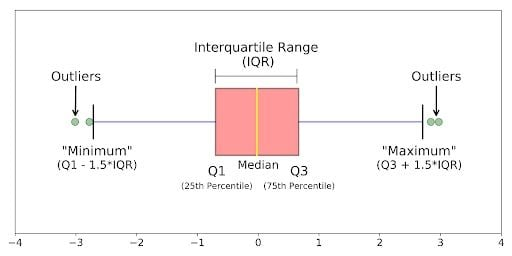

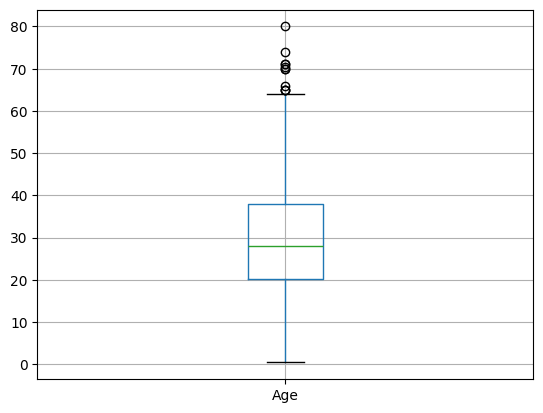

In [25]:
data[["Age"]].boxplot()
plt.show()

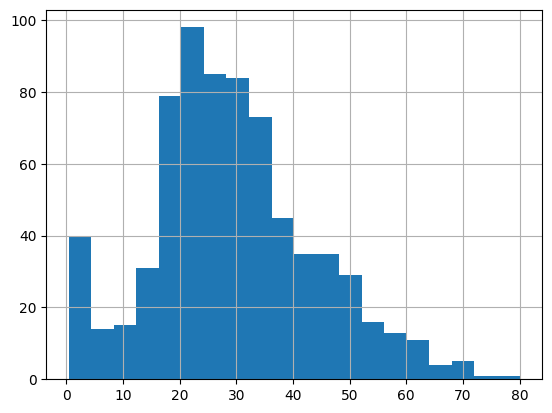

In [30]:
data["Age"].hist(bins=20)
plt.show()

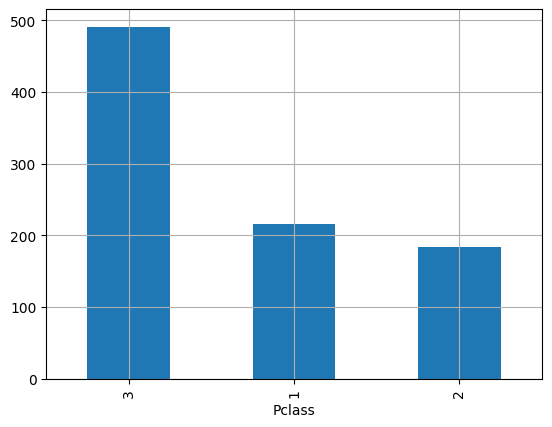

In [31]:
data['Pclass'].value_counts().plot.bar()
plt.grid()
plt.show()

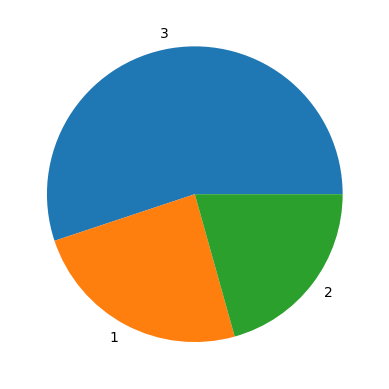

In [32]:
data['Pclass'].value_counts().plot.pie()
plt.show()

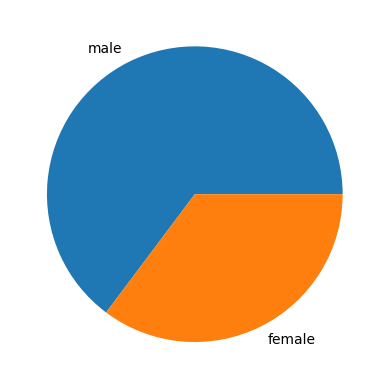

In [33]:
data['Sex'].value_counts().plot.pie()
plt.show()

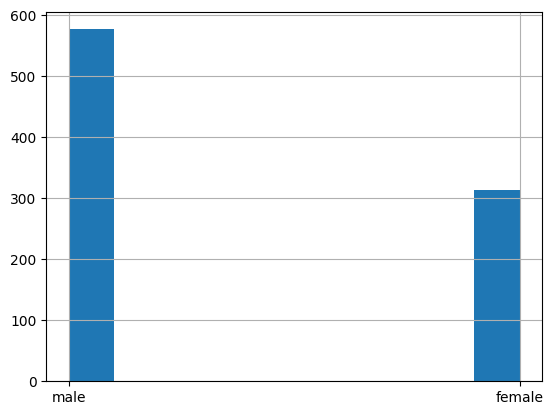

In [34]:
data["Sex"].hist()
plt.show()

In [36]:
data.groupby(['Sex'])['Age'].mean()

Sex
female    27.915709
male      30.726645
Name: Age, dtype: float64

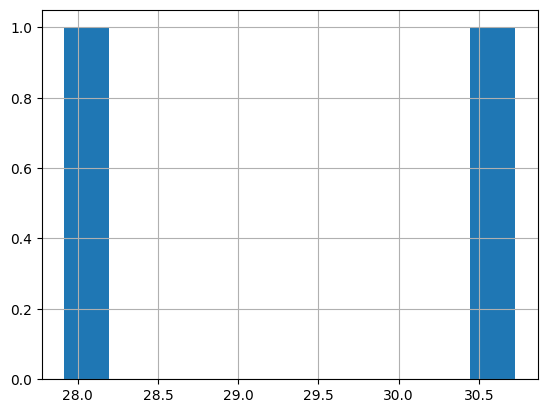

In [35]:
data.groupby(['Sex'])['Age'].mean().hist()
plt.show()